# EfficientNet-B0 — Image-Only Baseline on Mixed Balanced Multimodal Dataset
## Weighted vs Unweighted Loss Comparison

Runs the model **twice** — once with `pos_weight` (weighted) and once without —
then compares both side by side.

### Why compare?
The mixed balanced dataset has a 1:3 label ratio (legitimate:fraud).
- **Unweighted**: model may over-predict fraud (majority class)
- **Weighted** (`pos_weight (auto-computed from label ratio)`): penalises fraud misclassification less,
  balances precision/recall trade-off

This mirrors the tabular baseline methodology (none vs class_weight).

### Key diagnostic
`tab1_img0` subgroup F1 — expected near zero for both variants since the
image gives no fraud signal when only the transaction is fraudulent.

## 0 · Imports & reproducibility

In [1]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc as sk_auc

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from efficientnet_utils import (
    build_model, unfreeze_backbone,
    fit_model, run_test_evaluation, predict_probs,
    compute_metrics, tune_threshold,
    build_train_transform, build_val_transform, GradCAM,
)
from image_baseline_utils import subgroup_metrics
from mm_image_utils import (
    load_mm_splits, build_mm_dataloaders,
    make_loss_fn, subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")

Device : cpu  |  PyTorch 2.11.0+cpu


## 1 · Paths & config

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0

STAGE1_EPOCHS   = 5
STAGE1_LR       = 1e-3
STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20
BACKBONE_LR     = 1e-5
HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6

# Results dirs — separate folders so weights never overwrite each other
RESULTS_WEIGHTED   = PROJECT_ROOT / "notebook" / "results" / "mm_image_efficientnet_weighted"
RESULTS_UNWEIGHTED = PROJECT_ROOT / "notebook" / "results" / "mm_image_efficientnet_unweighted"
RESULTS_WEIGHTED.mkdir(parents=True, exist_ok=True)
RESULTS_UNWEIGHTED.mkdir(parents=True, exist_ok=True)

print("Weighted   results:", RESULTS_WEIGHTED)
print("Unweighted results:", RESULTS_UNWEIGHTED)

Weighted   results: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_weighted
Unweighted results: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_efficientnet_unweighted


## 2 · Load data

In [3]:
train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,   # baseline: no sampling correction
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

# Loss functions
from torch import nn
loss_fn_weighted   = make_loss_fn(train_df, device)          # pos_weight=0.33
loss_fn_unweighted = nn.BCEWithLogitsLoss().to(device)       # no weighting
print("Loss functions ready.")

train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}
val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  combos: {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}
test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}
Batches — train:225 val:48 test:47
  pos_weight = 0.563  (n_neg=2588, n_pos=4594)  [DOWN-weighting fraud (majority)]
Loss functions ready.


---
# Part A — Weighted (`pos_weight (auto-computed from label ratio)`)

## A1 · Stage 1

In [4]:
if (RESULTS_WEIGHTED / "stage1_best.pt").exists():
    print("Stage 1 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=True, freeze_backbone=True, dropout=0.4).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_tmp.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4,
    )
    model_tmp, h_s1 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_weighted, optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc", freeze_bn=False,
        model_save_path=RESULTS_WEIGHTED / "stage1_best.pt",
    )
    display(h_s1.round(4))

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Epoch 01 | lr=1.00e-03 | train_loss=0.3613 | val_loss=0.3261 | val_f1=0.8286 | val_roc_auc=0.8668
  ✓ Saved best model (epoch 1, val_roc_auc=0.8668)
Epoch 02 | lr=1.00e-03 | train_loss=0.3300 | val_loss=0.3174 | val_f1=0.8372 | val_roc_auc=0.8707
  ✓ Saved best model (epoch 2, val_roc_auc=0.8707)
Epoch 03 | lr=1.00e-03 | train_loss=0.3230 | val_loss=0.3170 | val_f1=0.8518 | val_roc_auc=0.8716
  ✓ Saved best model (epoch 3, val_roc_auc=0.8716)
Epoch 04 | lr=1.00e-03 | train_loss=0.3219 | val_loss=0.3126 | val_f1=0.8274 | val_roc_auc=0.8719
  ✓ Saved best model (epoch 4, val_roc_auc=0.8719)
Epoch 05 | lr=1.00e-03 | train_loss=0.3244 | val_loss=0.3171 | val_f1=0.8068 | val_roc_auc=0.8729
  ✓ Saved best model (epoch 5, val_roc_auc=0.8729)
Restored best weights (val_roc_auc=0.8729).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.3613,0.3261,0.7918,0.8615,0.7981,0.8286,0.8668
1,2,0.001,0.3300,0.3174,0.8024,0.8714,0.8055,0.8372,0.8707
2,3,0.001,0.3230,0.3170,0.8163,0.8671,0.8370,0.8518,0.8716
3,4,0.001,0.3219,0.3126,0.7991,0.9030,0.7634,0.8274,0.8719
4,5,0.001,0.3244,0.3171,0.7818,0.9136,0.7224,0.8068,0.8729


## A2 · Stage 2

In [5]:
if (RESULTS_WEIGHTED / "stage2_best.pt").exists():
    print("Stage 2 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
    model_tmp.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage1_best.pt", map_location=device))
    unfreeze_backbone(model_tmp)
    bp = [p for n, p in model_tmp.named_parameters() if "classifier" not in n]
    hp = list(model_tmp.classifier.parameters())
    opt2 = torch.optim.Adam([{"params":bp,"lr":BACKBONE_LR},{"params":hp,"lr":HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_tmp, h_s2 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_weighted, optimizer=opt2, device=device,
        epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", scheduler=sched, freeze_bn=True,
        model_save_path=RESULTS_WEIGHTED / "stage2_best.pt",
    )
    hist = pd.concat([h_s1, h_s2], ignore_index=True)
    hist["epoch"] = range(1, len(hist)+1)
    hist.to_csv(RESULTS_WEIGHTED / "training_history.csv", index=False)
    display(h_s2.round(4))

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Backbone unfrozen — all parameters now trainable. BN layers will be frozen in eval mode during training.
Epoch 01 | lr=1.00e-05 | train_loss=0.3093 | val_loss=0.3019 | val_f1=0.8440 | val_roc_auc=0.8726
  ✓ Saved best model (epoch 1, val_roc_auc=0.8726)
Epoch 02 | lr=9.94e-06 | train_loss=0.2973 | val_loss=0.3008 | val_f1=0.8536 | val_roc_auc=0.8734
  ✓ Saved best model (epoch 2, val_roc_auc=0.8734)
Epoch 03 | lr=9.76e-06 | train_loss=0.2938 | val_loss=0.2986 | val_f1=0.8337 | val_roc_auc=0.8715
Epoch 04 | lr=9.46e-06 | train_loss=0.2890 | val_loss=0.2932 | val_f1=0.8502 | val_roc_auc=0.8762
  ✓ Saved best model (epoch 4, val_roc_auc=0.8762)
Epoch 05 | lr=9.05e-06 | train_loss=0.2855 | val_loss=0.2948 | val_f1=0.8536 | val_roc_auc=0.8745
Epoch 06 | lr=8.55e-06 | train_loss=0.2832 | val_loss=0.2927 | val_f1=0.8488 | val_roc_auc=0.8753
Epoch 07 | lr=7.96e-06 | train_loss=0.2849 | val_loss=0.2929 | val_f1=0.8486 | val_roc_a

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.3093,0.3019,0.8150,0.9010,0.7939,0.8440,0.8726
1,2,0.0,0.2973,0.3008,0.8216,0.8849,0.8244,0.8536,0.8734
2,3,0.0,0.2938,0.2986,0.8050,0.9021,0.7750,0.8337,0.8715
3,4,0.0,0.2890,0.2932,0.8196,0.8925,0.8118,0.8502,0.8762
4,5,0.0,0.2855,0.2948,0.8223,0.8885,0.8212,0.8536,0.8745
5,6,0.0,0.2832,0.2927,0.8183,0.8931,0.8086,0.8488,0.8753
6,7,0.0,0.2849,0.2929,0.8183,0.8941,0.8076,0.8486,0.8753
7,8,0.0,0.2800,0.2950,0.8024,0.9076,0.7645,0.8299,0.8717
8,9,0.0,0.2793,0.2921,0.8097,0.8990,0.7865,0.8390,0.8757
9,10,0.0,0.2791,0.2934,0.8050,0.9051,0.7718,0.8331,0.8732


## A3 · Load saved model

In [7]:
model_w = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
model_w.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage2_best.pt", map_location=device))
model_w.eval()
history_w = pd.read_csv(RESULTS_WEIGHTED / "training_history.csv")

model_u = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
model_u.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage2_best.pt", map_location=device))
model_u.eval()
history_u = pd.read_csv(RESULTS_UNWEIGHTED / "training_history.csv")
print("Both models loaded.")

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\Desktop\\thesis\\multimodal-fraud-detection-thesis\\notebook\\results\\mm_image_efficientnet_unweighted\\stage2_best.pt'

## A4 · Training curves

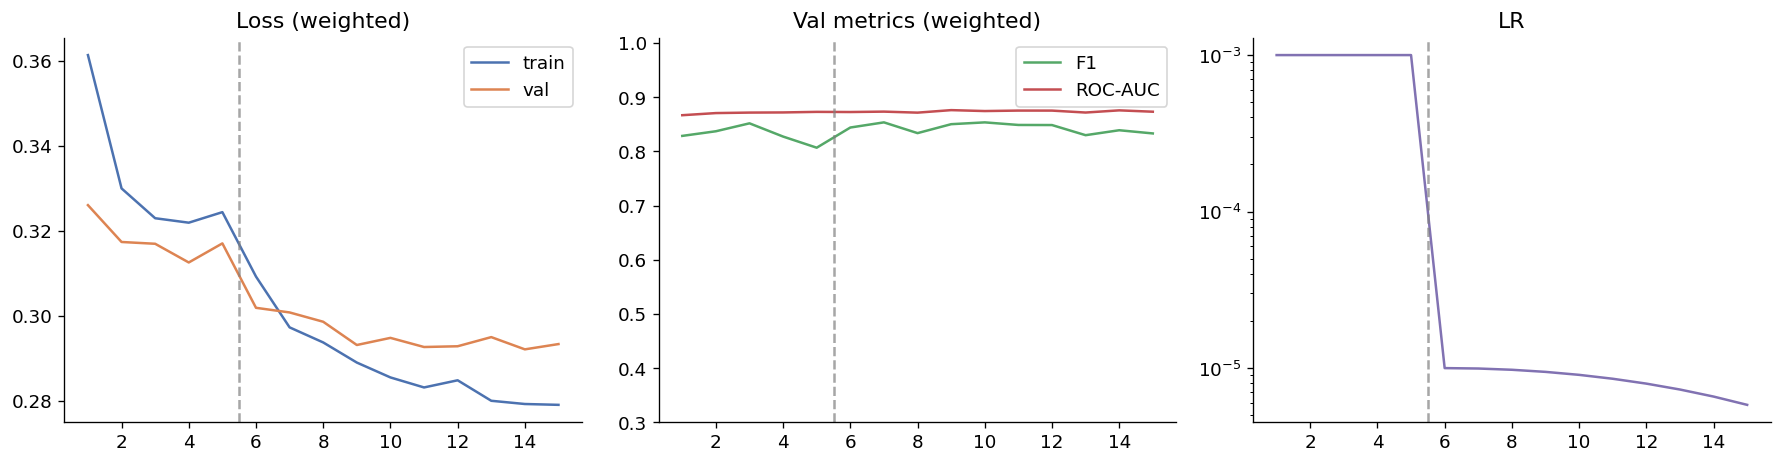

In [8]:
if "epoch_global" not in history_w.columns:
    history_w["epoch_global"] = range(1, len(history_w) + 1)
n_s1 = (history_w["epoch"] <= STAGE1_EPOCHS).sum()
ep   = history_w["epoch_global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ep, history_w["train_loss"], label="train", color="#4C72B0")
axes[0].plot(ep, history_w["val_loss"],   label="val",   color="#DD8452")
axes[0].set_title("Loss (weighted)"); axes[0].legend()
axes[1].plot(ep, history_w["val_f1"],      label="F1",      color="#55A868")
axes[1].plot(ep, history_w["val_roc_auc"], label="ROC-AUC", color="#C44E52")
axes[1].set_ylim(0.3, 1.01); axes[1].set_title("Val metrics (weighted)"); axes[1].legend()
axes[2].plot(ep, history_w["lr"], color="#8172B2")
axes[2].set_title("LR"); axes[2].set_yscale("log")
for ax in axes:
    ax.axvline(x=n_s1+0.5, color="gray", linestyle="--", alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## A5 · Threshold tuning & test evaluation

In [9]:
val_y_true, val_y_prob = predict_probs(model_w, val_loader, device)
thresh_w, sweep_w = tune_threshold(val_y_true, val_y_prob, metric="f1")
sweep_w.to_csv(RESULTS_WEIGHTED / "threshold_sweep.csv", index=False)

metrics_w = run_test_evaluation(
    model=model_w, test_loader=test_loader,
    loss_fn=loss_fn_weighted, device=device, threshold=thresh_w,
)
y_true_w, y_prob_w = predict_probs(model_w, test_loader, device)
pred_w = test_df.reset_index(drop=True).copy()
pred_w["y_true"] = y_true_w
pred_w["y_prob"] = y_prob_w
pred_w["y_pred"] = (pred_w["y_prob"] >= thresh_w).astype(int)
pred_w.to_csv(RESULTS_WEIGHTED / "test_predictions.csv", index=False)

sg_w = subgroup_by_combo(pred_w, thresh_w)
sg_w.to_csv(RESULTS_WEIGHTED / "subgroup_combo_type.csv", index=False)
display(sg_w.round(3))


Best threshold (f1): 0.35

── TEST METRICS ──────────────────────────────
  loss        : 0.2890
  accuracy    : 0.8311
  precision   : 0.8879
  recall      : 0.8348
  f1          : 0.8605
  roc_auc     : 0.8766
  confusion_matrix:
[[457  97]
 [152 768]]
──────────────────────────────────────────────


,combo_type,n_rows,label,precision,recall,f1,roc_auc
0,tab0_img0,554,0,0.0,0.000,0.000,NaN
1,tab0_img1,368,1,1.0,1.000,1.000,NaN
2,tab1_img0,185,1,1.0,0.178,0.303,NaN
3,tab1_img1,367,1,1.0,1.000,1.000,NaN


---
# Part B — Unweighted (no `pos_weight`)

## B1 · Stage 1

In [10]:
if (RESULTS_UNWEIGHTED / "stage1_best.pt").exists():
    print("Stage 1 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=True, freeze_backbone=True, dropout=0.4).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_tmp.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4,
    )
    model_tmp, h_s1 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_unweighted, optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc", freeze_bn=False,
        model_save_path=RESULTS_UNWEIGHTED / "stage1_best.pt",
    )
    display(h_s1.round(4))

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Epoch 01 | lr=1.00e-03 | train_loss=0.4910 | val_loss=0.4476 | val_f1=0.8348 | val_roc_auc=0.8598
  ✓ Saved best model (epoch 1, val_roc_auc=0.8598)
Epoch 02 | lr=1.00e-03 | train_loss=0.4454 | val_loss=0.4440 | val_f1=0.8367 | val_roc_auc=0.8610
  ✓ Saved best model (epoch 2, val_roc_auc=0.8610)
Epoch 03 | lr=1.00e-03 | train_loss=0.4416 | val_loss=0.4286 | val_f1=0.8461 | val_roc_auc=0.8696
  ✓ Saved best model (epoch 3, val_roc_auc=0.8696)
Epoch 04 | lr=1.00e-03 | train_loss=0.4359 | val_loss=0.4254 | val_f1=0.8484 | val_roc_auc=0.8704
  ✓ Saved best model (epoch 4, val_roc_auc=0.8704)
Epoch 05 | lr=1.00e-03 | train_loss=0.4356 | val_loss=0.4246 | val_f1=0.8462 | val_roc_auc=0.8715
  ✓ Saved best model (epoch 5, val_roc_auc=0.8715)
Restored best weights (val_roc_auc=0.8715).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.4910,0.4476,0.7898,0.8275,0.8423,0.8348,0.8598
1,2,0.001,0.4454,0.4440,0.7851,0.8035,0.8728,0.8367,0.8610
2,3,0.001,0.4416,0.4286,0.8070,0.8511,0.8412,0.8461,0.8696
3,4,0.001,0.4359,0.4254,0.8103,0.8556,0.8412,0.8484,0.8704
4,5,0.001,0.4356,0.4246,0.8084,0.8567,0.8360,0.8462,0.8715


## B2 · Stage 2

In [11]:
if (RESULTS_UNWEIGHTED / "stage2_best.pt").exists():
    print("Stage 2 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
    model_tmp.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage1_best.pt", map_location=device))
    unfreeze_backbone(model_tmp)
    bp = [p for n, p in model_tmp.named_parameters() if "classifier" not in n]
    hp = list(model_tmp.classifier.parameters())
    opt2 = torch.optim.Adam([{"params":bp,"lr":BACKBONE_LR},{"params":hp,"lr":HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_tmp, h_s2 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_unweighted, optimizer=opt2, device=device,
        epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", scheduler=sched, freeze_bn=True,
        model_save_path=RESULTS_UNWEIGHTED / "stage2_best.pt",
    )
    hist = pd.concat([h_s1, h_s2], ignore_index=True)
    hist["epoch"] = range(1, len(hist)+1)
    hist.to_csv(RESULTS_UNWEIGHTED / "training_history.csv", index=False)
    display(h_s2.round(4))

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Backbone unfrozen — all parameters now trainable. BN layers will be frozen in eval mode during training.
Epoch 01 | lr=1.00e-05 | train_loss=0.4174 | val_loss=0.4135 | val_f1=0.8520 | val_roc_auc=0.8732
  ✓ Saved best model (epoch 1, val_roc_auc=0.8732)
Epoch 02 | lr=9.94e-06 | train_loss=0.4068 | val_loss=0.4081 | val_f1=0.8487 | val_roc_auc=0.8745
  ✓ Saved best model (epoch 2, val_roc_auc=0.8745)
Epoch 03 | lr=9.76e-06 | train_loss=0.3974 | val_loss=0.4049 | val_f1=0.8507 | val_roc_auc=0.8758
  ✓ Saved best model (epoch 3, val_roc_auc=0.8758)
Epoch 04 | lr=9.46e-06 | train_loss=0.3904 | val_loss=0.4059 | val_f1=0.8497 | val_roc_auc=0.8741
Epoch 05 | lr=9.05e-06 | train_loss=0.3907 | val_loss=0.4038 | val_f1=0.8537 | val_roc_auc=0.8742
Epoch 06 | lr=8.55e-06 | train_loss=0.3878 | val_loss=0.4046 | val_f1=0.8519 | val_roc_auc=0.8747
Epoch 07 | lr=7.96e-06 | train_loss=0.3838 | val_loss=0.4024 | val_f1=0.8534 | val_roc_a

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.4174,0.4135,0.8190,0.8792,0.8265,0.8520,0.8732
1,2,0.0,0.4068,0.4081,0.8090,0.8478,0.8496,0.8487,0.8745
2,3,0.0,0.3974,0.4049,0.8163,0.8728,0.8297,0.8507,0.8758
3,4,0.0,0.3904,0.4059,0.8130,0.8616,0.8381,0.8497,0.8741
4,5,0.0,0.3907,0.4038,0.8210,0.8804,0.8286,0.8537,0.8742
5,6,0.0,0.3878,0.4046,0.8170,0.8697,0.8349,0.8519,0.8747
6,7,0.0,0.3838,0.4024,0.8210,0.8822,0.8265,0.8534,0.8739
7,8,0.0,0.3786,0.3992,0.8210,0.8830,0.8254,0.8533,0.8754
8,9,0.0,0.3772,0.3973,0.8216,0.8814,0.8286,0.8542,0.8765
9,10,0.0,0.3800,0.3955,0.8229,0.8834,0.8286,0.8551,0.8765


## B3 · Load saved model

In [12]:
model_w = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
model_w.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage2_best.pt", map_location=device))
model_w.eval()
history_w = pd.read_csv(RESULTS_WEIGHTED / "training_history.csv")

model_u = build_model(pretrained=False, freeze_backbone=False, dropout=0.4).to(device)
model_u.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage2_best.pt", map_location=device))
model_u.eval()
history_u = pd.read_csv(RESULTS_UNWEIGHTED / "training_history.csv")
print("Both models loaded.")

EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
EfficientNet-B0 | image_size=224 | in_features=1280 | dropout=0.4
Both models loaded.


## B4 · Training curves

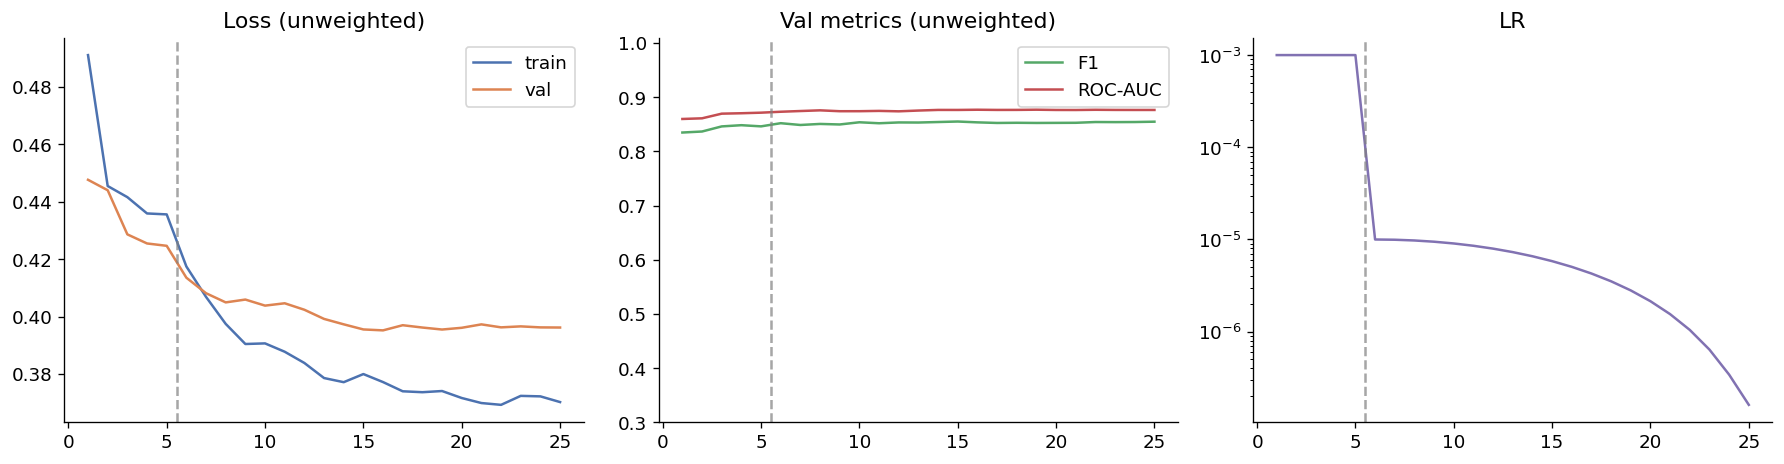

In [13]:
if "epoch_global" not in history_u.columns:
    history_u["epoch_global"] = range(1, len(history_u) + 1)
n_s1 = (history_u["epoch"] <= STAGE1_EPOCHS).sum()
ep   = history_u["epoch_global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ep, history_u["train_loss"], label="train", color="#4C72B0")
axes[0].plot(ep, history_u["val_loss"],   label="val",   color="#DD8452")
axes[0].set_title("Loss (unweighted)"); axes[0].legend()
axes[1].plot(ep, history_u["val_f1"],      label="F1",      color="#55A868")
axes[1].plot(ep, history_u["val_roc_auc"], label="ROC-AUC", color="#C44E52")
axes[1].set_ylim(0.3, 1.01); axes[1].set_title("Val metrics (unweighted)"); axes[1].legend()
axes[2].plot(ep, history_u["lr"], color="#8172B2")
axes[2].set_title("LR"); axes[2].set_yscale("log")
for ax in axes:
    ax.axvline(x=n_s1+0.5, color="gray", linestyle="--", alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_UNWEIGHTED / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## B5 · Threshold tuning & test evaluation

In [14]:
val_y_true, val_y_prob = predict_probs(model_u, val_loader, device)
thresh_u, sweep_u = tune_threshold(val_y_true, val_y_prob, metric="f1")
sweep_u.to_csv(RESULTS_UNWEIGHTED / "threshold_sweep.csv", index=False)

metrics_u = run_test_evaluation(
    model=model_u, test_loader=test_loader,
    loss_fn=loss_fn_unweighted, device=device, threshold=thresh_u,
)
y_true_u, y_prob_u = predict_probs(model_u, test_loader, device)
pred_u = test_df.reset_index(drop=True).copy()
pred_u["y_true"] = y_true_u
pred_u["y_prob"] = y_prob_u
pred_u["y_pred"] = (pred_u["y_prob"] >= thresh_u).astype(int)
pred_u.to_csv(RESULTS_UNWEIGHTED / "test_predictions.csv", index=False)

sg_u = subgroup_by_combo(pred_u, thresh_u)
sg_u.to_csv(RESULTS_UNWEIGHTED / "subgroup_combo_type.csv", index=False)
display(sg_u.round(3))


Best threshold (f1): 0.45

── TEST METRICS ──────────────────────────────
  loss        : 0.3871
  accuracy    : 0.8270
  precision   : 0.8809
  recall      : 0.8359
  f1          : 0.8578
  roc_auc     : 0.8830
  confusion_matrix:
[[450 104]
 [151 769]]
──────────────────────────────────────────────


,combo_type,n_rows,label,precision,recall,f1,roc_auc
0,tab0_img0,554,0,0.0,0.000,0.000,NaN
1,tab0_img1,368,1,1.0,1.000,1.000,NaN
2,tab1_img0,185,1,1.0,0.184,0.311,NaN
3,tab1_img1,367,1,1.0,1.000,1.000,NaN


---
# Part C — Weighted vs Unweighted comparison

## C1 · Overall metrics

,variant,threshold,accuracy,precision,recall,f1,roc_auc
0,Weighted,0.35,0.8311,0.8879,0.8348,0.8605,0.8766
1,Unweighted,0.45,0.8270,0.8809,0.8359,0.8578,0.8830


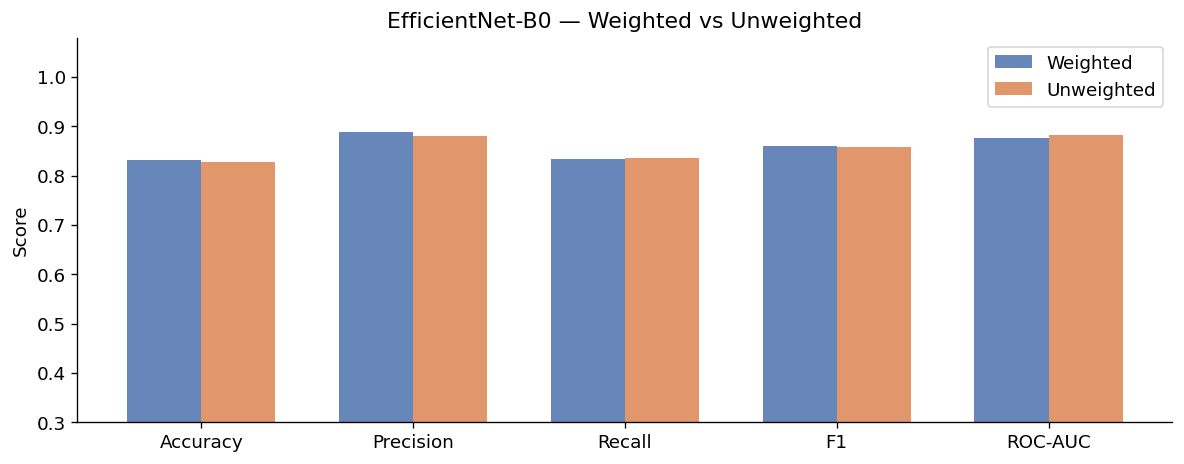

In [15]:
cmp = pd.DataFrame([
    {"variant": "Weighted",   "threshold": thresh_w,
     "accuracy": metrics_w["accuracy"], "precision": metrics_w["precision"],
     "recall":   metrics_w["recall"],   "f1":        metrics_w["f1"],
     "roc_auc":  metrics_w["roc_auc"]},
    {"variant": "Unweighted", "threshold": thresh_u,
     "accuracy": metrics_u["accuracy"], "precision": metrics_u["precision"],
     "recall":   metrics_u["recall"],   "f1":        metrics_u["f1"],
     "roc_auc":  metrics_u["roc_auc"]},
])
display(cmp.round(4))
cmp.to_csv(RESULTS_WEIGHTED.parent / "mm_image_efficientnet_weighted_vs_unweighted.csv", index=False)

metrics_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_plot)); width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x-width/2, cmp[cmp["variant"]=="Weighted"][metrics_plot].values[0],
       width, label="Weighted",   color="#4C72B0", alpha=0.85)
ax.bar(x+width/2, cmp[cmp["variant"]=="Unweighted"][metrics_plot].values[0],
       width, label="Unweighted", color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(["Accuracy","Precision","Recall","F1","ROC-AUC"])
ax.set_ylim(0.3, 1.08); ax.set_title("EfficientNet-B0 — Weighted vs Unweighted")
ax.set_ylabel("Score"); ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / "mm_image_efficientnet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## C2 · ROC curves comparison

In [1]:
fig, ax = plt.subplots(figsize=(7, 5))
fpr_w, tpr_w, _ = roc_curve(y_true_w, y_prob_w)
fpr_u, tpr_u, _ = roc_curve(y_true_u, y_prob_u)
ax.plot(fpr_w, tpr_w, color="#4C72B0", lw=2,
        label=f"Weighted   AUC={sk_auc(fpr_w,tpr_w):.4f}")
ax.plot(fpr_u, tpr_u, color="#DD8452", lw=2,
        label=f"Unweighted AUC={sk_auc(fpr_u,tpr_u):.4f}")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve comparison"); ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_roc_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

## C3 · Combo subgroup comparison
The most important comparison — does weighting help on `tab1_img0`?

In [2]:
COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (sg, label) in zip(axes, [(sg_w,"Weighted"),(sg_u,"Unweighted")]):
    colours = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"],
                  color=colours, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0,1.15); ax.set_title(f"F1 by combo — {label}")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

fig.legend(handles=[
    Patch(color="#4C72B0",label="tab0_img0 → label 0"),
    Patch(color="#C44E52",label="tab1_img1 → label 1 (both)"),
    Patch(color="#DD8452",label="tab1_img0 → label 1 (tab only)"),
    Patch(color="#55A868",label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.12), fontsize=9)
fig.suptitle("Combo subgroup F1 — Weighted vs Unweighted", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_combo_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

## C4 · Score distributions

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (y_true, y_prob, thresh, label) in zip(axes, [
    (y_true_w, y_prob_w, thresh_w, "Weighted"),
    (y_true_u, y_prob_u, thresh_u, "Unweighted"),
]):
    ax.hist(y_prob[y_true==0], bins=40, alpha=0.65, color="#4C72B0",
            label="Legitimate", density=True)
    ax.hist(y_prob[y_true==1], bins=40, alpha=0.65, color="#DD8452",
            label="Fraud",      density=True)
    ax.axvline(x=thresh, color="red", linestyle="--", label=f"t={thresh:.2f}")
    ax.set_xlabel("Predicted fraud probability")
    ax.set_title(f"Score distribution — {label}")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_score_dist_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

## C5 · Summary table

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
col_labels = ["Threshold","Accuracy","Precision","Recall","F1","ROC-AUC"]
cell_data  = [
    [f"{thresh_w:.2f}",
     f"{metrics_w['accuracy']:.4f}", f"{metrics_w['precision']:.4f}",
     f"{metrics_w['recall']:.4f}",   f"{metrics_w['f1']:.4f}",
     f"{metrics_w['roc_auc']:.4f}"],
    [f"{thresh_u:.2f}",
     f"{metrics_u['accuracy']:.4f}", f"{metrics_u['precision']:.4f}",
     f"{metrics_u['recall']:.4f}",   f"{metrics_u['f1']:.4f}",
     f"{metrics_u['roc_auc']:.4f}"],
]
tbl = ax.table(cellText=cell_data,
               rowLabels=["Weighted","Unweighted"],
               colLabels=col_labels,
               cellLoc="center", rowLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
ax.set_title("EfficientNet-B0 — Weighted vs Unweighted  |  mm mixed balanced  |  seed={SEED}",
             fontsize=11, pad=18)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / "mm_image_efficientnet_final_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All results saved.")

NameError: name 'plt' is not defined